In [2]:
import os
import numpy as np
import pandas as pd
import torch

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [5]:
!pip install ipywidgets


  Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

c:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df = pd.read_csv(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\data\cleaned_complaints.csv"
)

In [7]:
df = df.dropna()

In [8]:
X = df["clean_text"]

y = df["Agency Name"]

In [9]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [11]:
MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

c:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\G VARSHIT HARIPRASAD\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [12]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

In [13]:
class ComplaintDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        return {
            "input_ids": torch.tensor(
                self.encodings["input_ids"][idx]
            ),

            "attention_mask": torch.tensor(
                self.encodings["attention_mask"][idx]
            ),

            "labels": torch.tensor(
                self.labels[idx]
            )
        }

    def __len__(self):

        return len(self.labels)

In [14]:
train_dataset = ComplaintDataset(
    train_encodings,
    y_train.tolist()
)

test_dataset = ComplaintDataset(
    test_encodings,
    y_test.tolist()
)

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3133.25it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=4,

    per_device_eval_batch_size=4,

    num_train_epochs=1,

    weight_decay=0.01,

    load_best_model_at_end=True
)

In [17]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy": acc
    }

In [18]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.003864,0.000004,1.000000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


TrainOutput(global_step=98732, training_loss=0.008995546489199932, metrics={'train_runtime': 13294.662, 'train_samples_per_second': 29.706, 'train_steps_per_second': 7.426, 'total_flos': 5277062078523300.0, 'train_loss': 0.008995546489199932, 'epoch': 1.0})

In [20]:
predictions = trainer.predict(
    test_dataset
)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

In [22]:
print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       884
           1       1.00      1.00      1.00        54
           2       1.00      1.00      1.00      9752
           3       1.00      1.00      1.00      1266
           4       1.00      1.00      1.00     64063
           5       1.00      1.00      1.00      2681
           6       1.00      1.00      1.00      8563
           7       1.00      1.00      1.00      7414
           8       1.00      1.00      1.00       737
           9       1.00      1.00      1.00      1547
          10       1.00      1.00      1.00      1771

    accuracy                           1.00     98732
   macro avg       1.00      1.00      1.00     98732
weighted avg       1.00      1.00      1.00     98732



In [24]:
model.save_pretrained(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\models\roberta_model"
)

tokenizer.save_pretrained(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\models/roberta_tokenized_model"
)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.14it/s]


('C:\\Users\\G VARSHIT HARIPRASAD\\Desktop\\Infotact Solutions Project\\Month 2 - April\\AI Sentiment Analysis System 2\\models/roberta_tokenized_model\\tokenizer_config.json',
 'C:\\Users\\G VARSHIT HARIPRASAD\\Desktop\\Infotact Solutions Project\\Month 2 - April\\AI Sentiment Analysis System 2\\models/roberta_tokenized_model\\tokenizer.json')

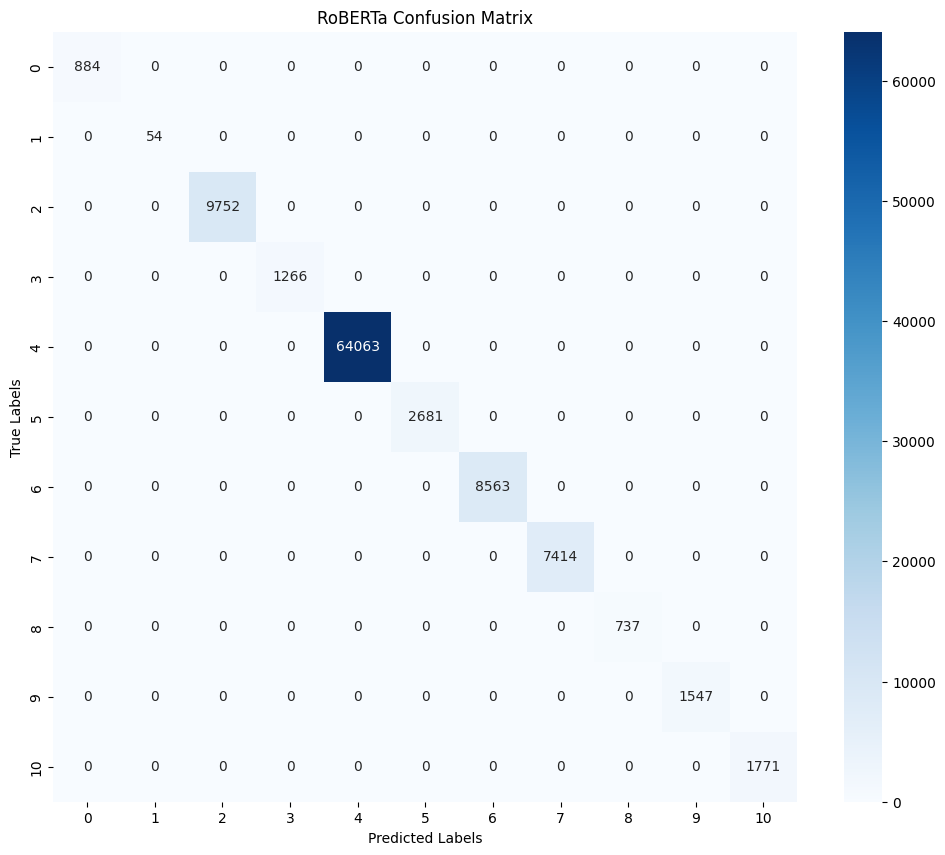

In [23]:
cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "RoBERTa Confusion Matrix"
)

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

# Save plot
plt.savefig(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\outputs\roberta_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close()